# 📄 AI Documents Chatbot — LangChain + RAG

Upload a document, ask questions, and get answers grounded **only** in that document.

**Stack:** LangChain · ChromaDB · HuggingFace embeddings (`all-MiniLM-L6-v2`) · Groq LLM (`openai/gpt-oss-20b`)

This notebook is the end-to-end version of my Streamlit project (`Ai-Documents-Chatbot-Langchain`). Same pipeline, same parameters — the Streamlit UI is replaced by notebook cells.

📂 **Full project folder (Streamlit app, loaders, RAG modules, tests, workflow diagram):** [github.com/ENGABHAY/Ai-Documents-Chatbot-Langchain](https://github.com/ENGABHAY/Ai-Documents-Chatbot-Langchain)

### Pipeline

```
Phase 1 — Ingestion (runs once per file)
  file ─► load (by extension) ─► split (1000 / 150) ─► embed (MiniLM) ─► store (ChromaDB)

Phase 2 — Question answering (runs per question)
  question ─► retrieve (MMR, k=5) ─► context-only prompt ─► Groq LLM ─► answer
```

| Section | What it does | Original file |
|---|---|---|
| 1 | Install + API key + imports | `requirements.txt`, `.env` |
| 2 | Document loaders (PDF, TXT, DOCX, CSV, XLSX, PPTX, HTML) | `loaders/` |
| 3–7 | Splitter, embeddings, vector store, prompt, RAG chain | `rag/` |
| 8 | Pick a file, build the pipeline, ask questions | `app.py`, `testfiles/` |

## Problem domain

**Use case: answering questions from your own documents.**

Students, researchers and professionals spend a lot of time hunting through long documents (research papers, reports, notes, spreadsheets) for one specific fact. Keyword search misses paraphrased wording, and asking a general-purpose LLM directly is risky because it doesn't have the document and may answer from memory, or make something up.

This chatbot uses Retrieval-Augmented Generation (RAG) to fix both problems. It retrieves the relevant passages from the uploaded file and tells the LLM to answer only from them, or to say it couldn't find the answer.

| | |
|---|---|
| **Who it helps** | Anyone who needs quick, checkable answers from a private or domain-specific document without reading it end to end |
| **Demo document** | *Attention Is All You Need* (the Transformer paper), a dense technical paper with exact facts (model sizes, scores) that are easy to verify |
| **Scope** | One document at a time: PDF, TXT, DOCX, CSV, XLSX/XLS, PPTX, HTML |

## 1. Setup

In [1]:
%pip install -q langchain langchain-community langchain-core langchain-chroma langchain-huggingface langchain-groq langchain-text-splitters chromadb sentence-transformers pypdf docx2txt python-docx openpyxl xlrd pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# Optional — only needed if you want to chat with .pptx or .html files (large install).
# Uncomment the line below, run it once, then restart the kernel.
# %pip install -q unstructured python-pptx

### Groq API key
Paste your key in .env file in same folder (free key at [console.groq.com](https://console.groq.com)).

In [14]:
import os
from dotenv import load_dotenv, find_dotenv

load_dotenv(find_dotenv(usecwd=True),override=True)   # reads GROQ_API_KEY from your .env file

if os.getenv("GROQ_API_KEY"):
    print("✅ Groq API key loaded from .env")
else:
    print("⚠️ GROQ_API_KEY not found. Check your .env file.")

✅ Groq API key loaded from .env


In [3]:
import shutil
import urllib.request
from pathlib import Path

import pandas as pd

from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableLambda

from langchain_community.document_loaders import (
    PyPDFLoader,
    TextLoader,
    Docx2txtLoader,
    CSVLoader,
)
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma
from langchain_groq import ChatGroq

print("Imports OK")

C:\Users\kadam\AppData\Local\Temp\ipykernel_10024\2380794397.py:12: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import (
d:\VS code\Ai-Documents-Chatbot-Langchain\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports OK


**Observation — setup**

- Packages installed and imported cleanly on Python 3.13 in the project's virtual environment.
- The Groq key is loaded from `.env`, so no secret is stored in the notebook.
- Two warnings appear, both harmless: `langchain-community` is being sunset (the loaders still work; the longer-term fix is moving to standalone integration packages), and a `tqdm` notice that only affects how progress bars look (`ipywidgets` fixes it).

## 2. Document loaders  *(from `loaders/`)*

`load_file()` looks at the file extension and routes to the right loader. Excel gets a custom loader (one `Document` per sheet).

In [4]:
def load_excel(file_path: str):
    """Read every sheet of an Excel file into one Document per sheet."""
    excel_file = pd.ExcelFile(file_path)
    documents = []

    for sheet_name in excel_file.sheet_names:
        df = pd.read_excel(file_path, sheet_name=sheet_name)
        text = df.to_string(index=False)

        documents.append(
            Document(
                page_content=text,
                metadata={"source": file_path, "sheet": sheet_name},
            )
        )

    return documents


def load_file(file_path: str):
    """Route a file to the correct loader based on its extension."""
    extension = Path(file_path).suffix.lower()

    if extension == ".pdf":
        return PyPDFLoader(file_path).load()

    elif extension == ".txt":
        return TextLoader(file_path, encoding="utf-8").load()

    elif extension == ".docx":
        return Docx2txtLoader(file_path).load()

    elif extension == ".csv":
        return CSVLoader(file_path).load()

    elif extension in [".xlsx", ".xls"]:
        return load_excel(file_path)

    elif extension == ".pptx":
        # imported here so PDF/TXT/etc. work without the optional 'unstructured' install
        from langchain_community.document_loaders import UnstructuredPowerPointLoader
        return UnstructuredPowerPointLoader(file_path).load()

    elif extension in [".html", ".htm"]:
        from langchain_community.document_loaders import UnstructuredHTMLLoader
        return UnstructuredHTMLLoader(file_path).load()

    else:
        raise ValueError(f"Unsupported file type: {extension}")

## 3. Text splitter  *(from `rag/splitter.py`)*

Chunks of 1000 characters with 150 overlap, so context isn't cut off mid-thought at chunk boundaries.

In [5]:
def split_documents(documents):
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=1000,
        chunk_overlap=150,
    )
    return splitter.split_documents(documents)

## 4. Embeddings  *(from `rag/embeddings.py`)*

Free, local sentence-transformer model (downloads ~90 MB on first run). No embedding API needed.

In [6]:
def get_embeddings():
    return HuggingFaceEmbeddings(
        model_name="sentence-transformers/all-MiniLM-L6-v2"
    )

## 5. Vector store + retriever  *(from `rag/vectorstore.py`)*

Chunks are embedded and stored in ChromaDB (`./chroma_db`). The retriever uses **MMR** (Maximal Marginal Relevance): it fetches 20 candidates and returns the 5 that are relevant *and* diverse.

> Small notebook tweak: the collection is reset each time this runs, so re-running with a different file never mixes old chunks into new answers.

In [7]:
PERSIST_DIR = "./chroma_db"
COLLECTION_NAME = "doc_chatbot"


def create_vectorstore(documents):
    embeddings = get_embeddings()

    # start clean so old chunks from a previous run/file don't leak into retrieval
    try:
        Chroma(
            collection_name=COLLECTION_NAME,
            embedding_function=embeddings,
            persist_directory=PERSIST_DIR,
        ).delete_collection()
    except Exception:
        pass

    return Chroma.from_documents(
        documents=documents,
        embedding=embeddings,
        collection_name=COLLECTION_NAME,
        persist_directory=PERSIST_DIR,
    )


def create_retriever(vectorstore):
    return vectorstore.as_retriever(
        search_type="mmr",
        search_kwargs={"k": 5, "fetch_k": 20},
    )

## 6. Prompt  *(from `rag/prompt.py`)*

A strict, context-only prompt — the model must refuse instead of guessing.

In [8]:
prompt = ChatPromptTemplate.from_template("""
You are a document question-answering assistant.

Answer the question ONLY using the provided context.

Rules:
1. Do not use outside knowledge.
2. Do not make up information.
3. If the answer is not present in the context, say:
   "I could not find the answer in the uploaded file."

Context:
{context}

Question:
{question}

Answer:
""")

## 7. RAG chain  *(from `rag/chain.py`)*

`question ─► retriever ─► format chunks ─► prompt ─► Groq LLM ─► string`

In [11]:
def format_docs(documents):
    return "\n\n".join(document.page_content for document in documents)


def create_rag_chain(retriever):
    llm = ChatGroq(
        model="openai/gpt-oss-20b",
        temperature=0,
    )

    rag_chain = (
        {
            "context": retriever | RunnableLambda(format_docs),
            "question": RunnableLambda(lambda x: x),
        }
        | prompt
        | llm
        | StrOutputParser()
    )

    return rag_chain

## 8. Run the chatbot

### 8.1 Quick LLM connection test  *(from `testfiles/test_llm.py`)*

In [15]:
llm_test = ChatGroq(model="openai/gpt-oss-20b", temperature=0)
print(llm_test.invoke("Explain RAG in one sentence.").content)

RAG (Retrieval‑Augmented Generation) is a technique that first retrieves relevant documents from a knowledge base and then feeds them into a generative model, enabling the system to produce more accurate, context‑aware responses.


**Observation — LLM connection**

The model returned a correct one-line definition of RAG, so the API key, network access and the `openai/gpt-oss-20b` model name all work. Running this test first isolates LLM problems from retrieval problems if something fails later.

### 8.2 Choose the document

- Leave `FILE_PATH = None` to auto-download the sample paper (*Attention Is All You Need*) — the same file used in the project.
- Or set `FILE_PATH = "your_file.pdf"` (PDF, TXT, DOCX, CSV, XLSX/XLS, PPTX, HTML).
- On Google Colab, set `UPLOAD_IN_COLAB = True` to get an upload dialog.

> **This run:** used the local copy of the paper at `data/uploads/`. To reproduce elsewhere, put any file at that path (or point `FILE_PATH` at your own file), or set `FILE_PATH = None` to download the paper from arXiv.

In [17]:
FILE_PATH = "data/uploads/NIPS-2017-attention-is-all-you-need-Paper.pdf"   # None = download sample paper
UPLOAD_IN_COLAB = False     # True = open the Colab file-upload dialog

SAMPLE_URL = "https://arxiv.org/pdf/1706.03762"
SAMPLE_PATH = "data/uploads/attention_is_all_you_need.pdf"

if UPLOAD_IN_COLAB:
    from google.colab import files
    FILE_PATH = next(iter(files.upload()))

elif FILE_PATH is None:
    FILE_PATH = SAMPLE_PATH
    if not Path(FILE_PATH).exists():
        Path(FILE_PATH).parent.mkdir(parents=True, exist_ok=True)
        req = urllib.request.Request(SAMPLE_URL, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(req) as r, open(FILE_PATH, "wb") as f:
            f.write(r.read())
        print("Downloaded sample paper.")

assert Path(FILE_PATH).exists(), f"File not found: {FILE_PATH}"
print("Using file:", FILE_PATH)

Using file: data/uploads/NIPS-2017-attention-is-all-you-need-Paper.pdf


### 8.3 Build the pipeline

Load → split → embed & store → retriever → RAG chain (the same 5 steps `app.py` runs after an upload).

In [18]:
# 1. Load
documents = load_file(FILE_PATH)
print(f"Loaded {len(documents)} document(s)/page(s)")

# 2. Split
chunks = split_documents(documents)
print(f"Split into {len(chunks)} chunks "
      f"(avg {sum(len(c.page_content) for c in chunks) // len(chunks)} chars)")

# 3. Embed + store
vectorstore = create_vectorstore(chunks)
print("Stored chunks in ChromaDB")

# 4. Retriever
retriever = create_retriever(vectorstore)

# 5. RAG chain
rag_chain = create_rag_chain(retriever)
print("✅ RAG chain ready")

Loaded 11 document(s)/page(s)
Split into 40 chunks (avg 894 chars)


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 925.25it/s]


Stored chunks in ChromaDB
✅ RAG chain ready


**Observation — ingestion**

| Stage | Result |
|---|---|
| Pages loaded | 11 (one `Document` per PDF page) |
| Chunks created | 40 (about 3.6 per page) |
| Average chunk size | 894 characters (limit is 1000) |

- The average sits close to the 1000-character cap, so the splitter is filling chunks rather than producing tiny fragments. The 150-character overlap keeps sentences that cross a boundary intact.
- The embedding model ran locally (no embedding API cost). The Hugging Face "unauthenticated requests" warning is only a rate-limit notice; setting `HF_TOKEN` removes it.
- Chunks were stored in ChromaDB and the RAG chain was built without errors.

### 8.4 Inspect retrieval  *(from `testfiles/test_rag.py`)*
See exactly which chunks the retriever hands to the LLM.

In [19]:
query = "What is self-attention?"

docs = retriever.invoke(query)

for i, doc in enumerate(docs, start=1):
    print(f"\n{'=' * 70}\nRETRIEVED CHUNK {i}\n{'=' * 70}")
    print(doc.page_content[:500], "...")
    print(f"Source: {doc.metadata.get('source')} | page: {doc.metadata.get('page_label', doc.metadata.get('sheet', '-'))}")


RETRIEVED CHUNK 1
block, computing hidden representations in parallel for all input and output positions. In these models,
the number of operations required to relate signals from two arbitrary input or output positions grows
in the distance between positions, linearly for ConvS2S and logarithmically for ByteNet. This makes
it more difﬁcult to learn dependencies between distant positions [ 11]. In the Transformer this is
reduced to a constant number of operations, albeit at the cost of reduced effective resolutio ...
Source: data/uploads/NIPS-2017-attention-is-all-you-need-Paper.pdf | page: 2

RETRIEVED CHUNK 2
convolution is equal to the combination of a self-attention layer and a point-wise feed-forward layer,
the approach we take in our model.
As side beneﬁt, self-attention could yield more interpretable models. We inspect attention distributions
from our models and present and discuss examples in the appendix. Not only do individual attention
heads clearly learn to perform differe

**Observation — retrieval quality** (query: *"What is self-attention?"*)

- **Chunk 1 (page 2) is the right hit.** It is the background section where the paper defines self-attention. The printout is cut at 500 characters, so the definition itself sits further down that chunk.
- **Chunks 2 and 5 (pages 7 and 4)** are relevant: the "why self-attention" discussion and the multi-head attention description.
- **Chunks 3 and 4 are weak matches:** the positional-encoding formula (page 6) and the reference list (page 10). MMR deliberately trades some relevance for diversity, and with `k=5` on a 40-chunk document it fills the last slots with marginal chunks.
- The LLM ignored that noise in 8.5, but on a larger document this is where wrong or diluted answers would come from.
- PDF extraction leaves artifacts: ligatures (`ﬁ` in "difﬁcult"), odd spacing (`[ 11]`) and flattened math (the positional-encoding formula). None of it broke retrieval here, but it is worth cleaning in production.

### 8.5 Ask questions

The first three questions are for the sample paper. The last one is **not** in the paper on purpose — the bot should refuse instead of answering from outside knowledge.

In [20]:
def ask(question):
    print(f"Q: {question}")
    print(f"A: {rag_chain.invoke(question)}\n")


ask("What is self-attention?")
ask("How many attention heads does the base Transformer model use?")
ask("What BLEU score did the big Transformer model get on English-to-German translation?")
ask("Who won the FIFA World Cup in 2018?")   # not in the document -> should refuse

Q: What is self-attention?
A: Self‑attention, also called intra‑attention, is an attention mechanism that relates different positions of a single sequence in order to compute a representation of that sequence.

Q: How many attention heads does the base Transformer model use?
A: The base Transformer model uses **8 attention heads**.

Q: What BLEU score did the big Transformer model get on English-to-German translation?
A: The big Transformer model achieved a BLEU score of **28.4** on the English‑to‑German translation task.

Q: Who won the FIFA World Cup in 2018?
A: I could not find the answer in the uploaded file.



**Observation — question answering**

| # | Question | Bot answer | Checked against the paper | Result |
|---|---|---|---|---|
| 1 | What is self-attention? | Relates different positions of a single sequence to compute a representation of it | Matches the definition in the page-2 background section | ✅ Correct |
| 2 | Attention heads in the base Transformer? | 8 | Paper uses h = 8 for the base model | ✅ Correct |
| 3 | BLEU of the big model, English→German? | 28.4 | Paper reports 28.4 | ✅ Correct |
| 4 | Who won the 2018 FIFA World Cup? | "I could not find the answer in the uploaded file." | Not in the paper | ✅ Correct refusal |

- All three in-document answers match the source, and the numeric answers are exact rather than approximate.
- The out-of-scope question was refused with the exact sentence the prompt specifies. The model did not fall back on its own knowledge, which is the main thing a document chatbot must get right. The fixed sentence also makes "no answer" easy to detect in code.
- Answers are short and factual. Four questions make a smoke test, not a benchmark, so read this as "the pipeline works", not as an accuracy figure.

### 8.6 Your own questions *(optional interactive chat)*
Set `RUN_INTERACTIVE_CHAT = True` and run this cell. Type `exit` to stop. (Left `False` so **Run All** doesn't pause for input.)

In [ ]:
RUN_INTERACTIVE_CHAT = False 

if RUN_INTERACTIVE_CHAT:
    while True:
        question = input("\nYou: ").strip()
        if question.lower() in {"exit", "quit", "q", ""}:
            print("Chat ended.")
            break
        print("Bot:", rag_chain.invoke(question))

Bot: I could not find the answer in the uploaded file.
Bot: I could not find the answer in the uploaded file.
Bot: Self‑attention (also called intra‑attention) is an attention mechanism that relates different positions of a single sequence in order to compute a representation of that sequence.
Bot: Q, K, V are the matrices of **queries (Q)**, **keys (K)**, and **values (V)** that are used in the attention computation.
Bot: I could not find the answer in the uploaded file.
Chat ended.


**Observation — interactive session**

The output above comes from an earlier interactive run (the flag was `True` for that run; it is `False` now so *Run All* doesn't wait for input). It shows five replies: two document-grounded answers (self-attention and the Q/K/V definitions) and three uses of the standard refusal sentence. Every reply was either a grounded answer or the fixed refusal, and none pulled in outside knowledge. One caution: the strict prompt can also refuse an in-document question if retrieval misses the right chunk, so refusals are worth spot-checking against the source.

## Streamlit app screenshots

The same pipeline runs behind the Streamlit app in `app.py` (`streamlit run app.py`). Below is the app in use: upload a file, wait for processing, then ask questions.

**1. Landing page** — Upload any supported document (PDF, TXT, DOCX, CSV, XLSX, PPTX, HTML).

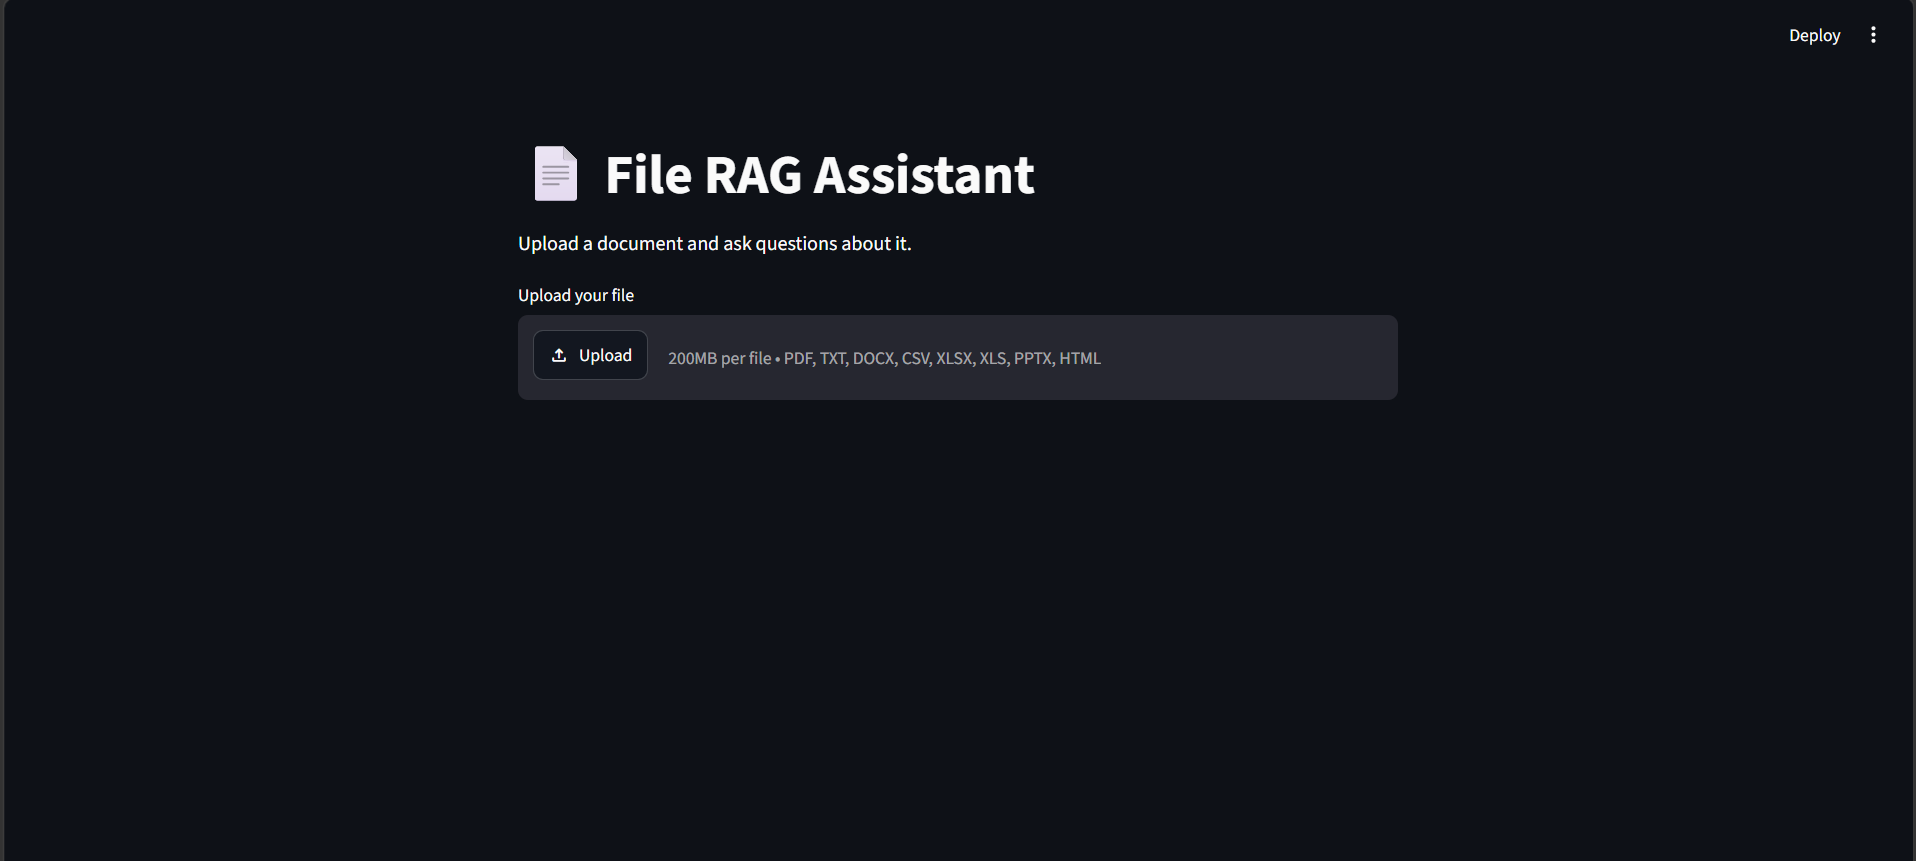

**2. File processed** — The file is loaded, chunked, embedded and stored, ready for questions.

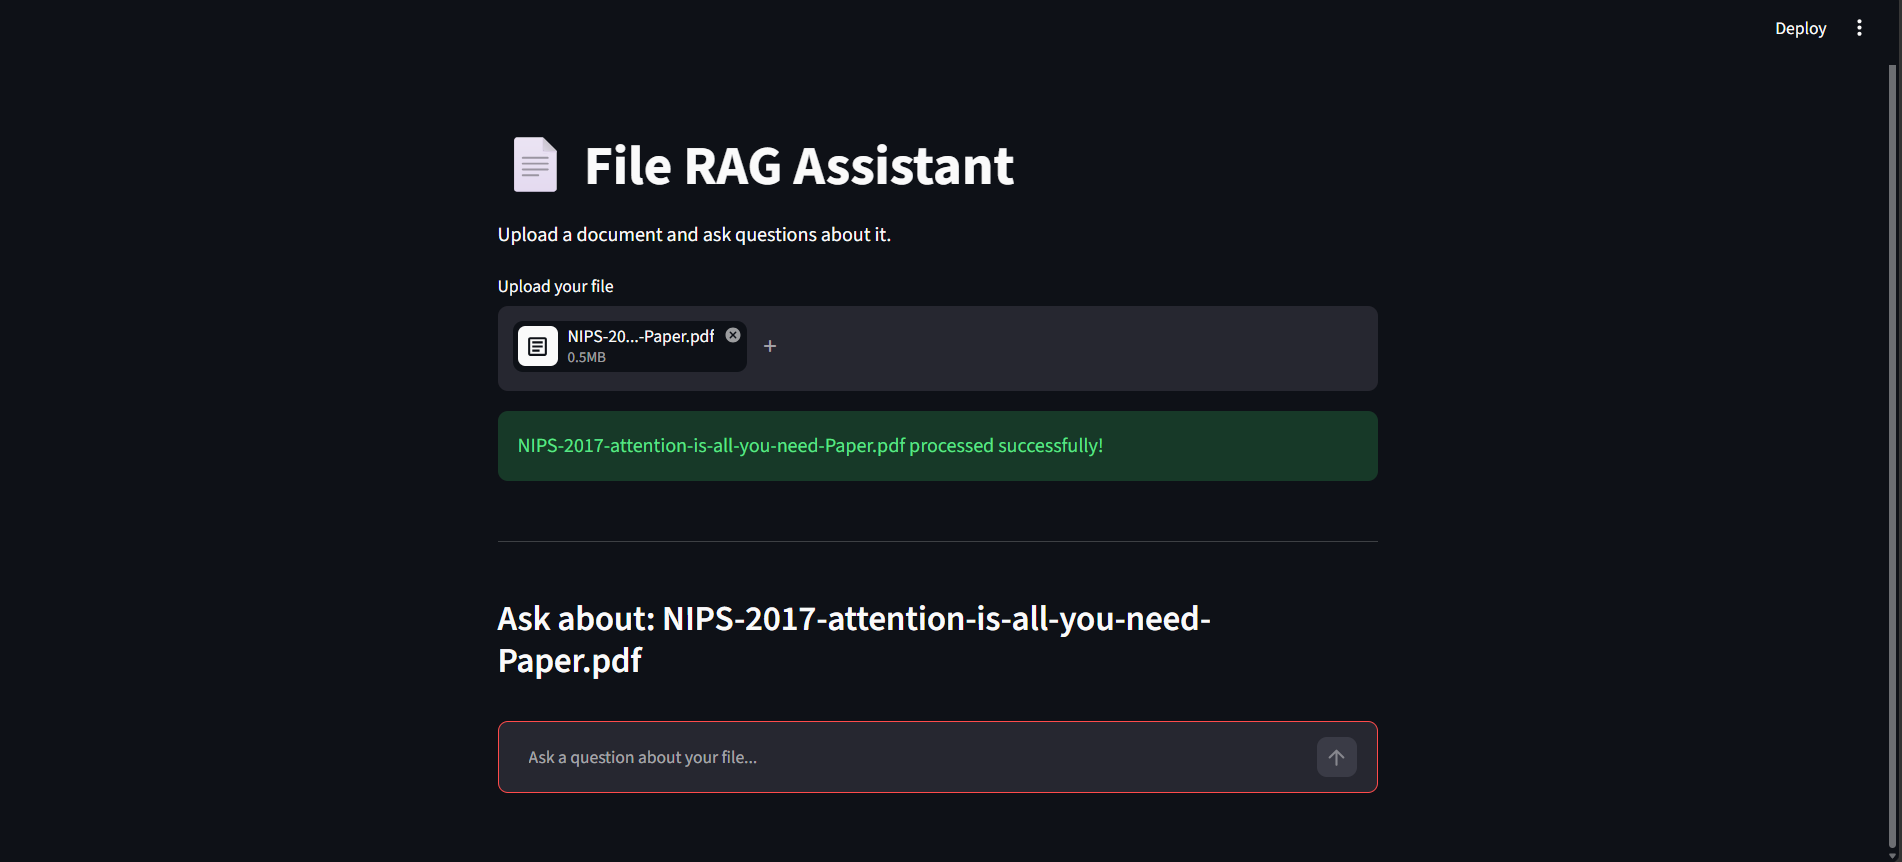

**3. Question and answer** — Answers are grounded in the uploaded document.

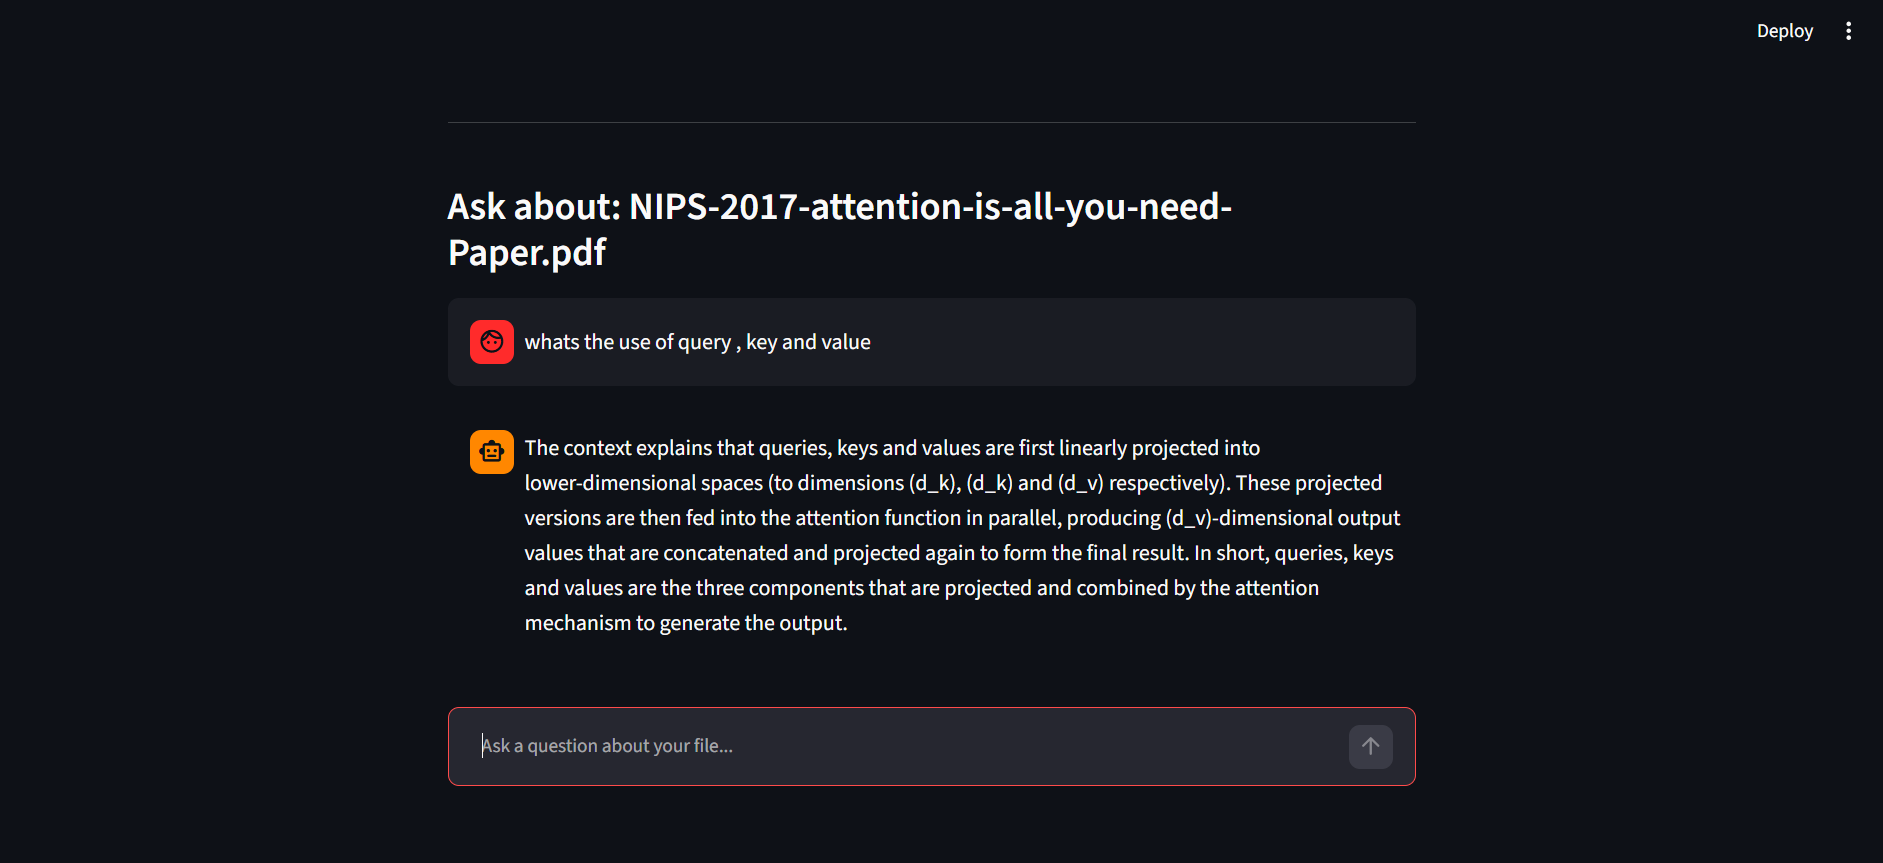

In [23]:
from pathlib import Path
from IPython.display import Image, Markdown, display

screens = [
    ("1. Landing page", "Assets/landing_page.png",
     "Upload any supported document (PDF, TXT, DOCX, CSV, XLSX, PPTX, HTML)."),
    ("2. File processed", "Assets/file_uploaded.png",
     "The file is loaded, chunked, embedded and stored, ready for questions."),
    ("3. Question and answer", "Assets/qa_page.png",
     "Answers are grounded in the uploaded document."),
]

for title, path, caption in screens:
    if Path(path).exists():
        display(Markdown(f"**{title}** — {caption}"))
        display(Image(filename=path, width=800))
    else:
        print(f"Missing image: {path}")

## Summary

- **Ingestion:** file → loader (by extension) → `RecursiveCharacterTextSplitter` (1000/150) → `all-MiniLM-L6-v2` embeddings → ChromaDB.
- **Answering:** question → MMR retriever (k=5, fetch_k=20) → context-only prompt → Groq `openai/gpt-oss-20b` (temperature 0) → answer.
- **Grounding:** the prompt forces *"I could not find the answer in the uploaded file."* for anything outside the document.
- **Original app:** the same functions power the Streamlit UI in `app.py` (`streamlit run app.py`).

## Design choices

| Component | Choice | Why |
|---|---|---|
| Orchestration | LangChain | Chains the steps as `retriever → prompt → LLM → parser`, so each part can be swapped independently |
| Loaders | One loader per file type, chosen by extension; Excel read one sheet per document | Users bring documents in many formats |
| Chunking | `RecursiveCharacterTextSplitter`, 1000 characters with 150 overlap | Keeps paragraphs and sentences together, and the overlap stops answers being cut at chunk boundaries (this run: 40 chunks, 894 characters on average) |
| Embeddings | `all-MiniLM-L6-v2`, run locally | Small (~90 MB), no API cost, good enough for semantic search on short passages |
| Vector store | ChromaDB, persisted to disk | Runs locally with no server to set up |
| Retrieval | MMR, `k=5`, `fetch_k=20` | Returns relevant and varied chunks instead of five near-duplicates. The trade-off: some weaker chunks slip in (see 8.4) |
| Prompt | Context-only, with a fixed refusal sentence | Reduces hallucination and makes "not found" easy to detect (see the FIFA question in 8.5) |
| LLM | Groq `openai/gpt-oss-20b`, temperature 0 | Hosted inference, so no local GPU is needed. Temperature 0 gives consistent, factual answers |
| Interface | Streamlit (`app.py`) | Fastest route to a chat UI; the retriever is kept in `session_state`, so a file is processed once per upload |
| Delivery | This notebook plus the GitHub repo | The notebook is the runnable submission; the repo holds the full app |

## Limitations and next steps

| Area | What was observed | Next step |
|---|---|---|
| Evaluation | Only 4 fixed questions plus a short interactive session; no metrics | Build a 30–50 question set with reference answers and score correctness and faithfulness (for example with RAGAS) |
| Retrieval noise | 2 of 5 chunks in 8.4 were weak matches, including the reference list | Tune `k` and `fetch_k`, try a relevance score threshold, drop reference pages, add a reranker |
| Source citations | Answers don't say where they came from, though page metadata is already retrieved | Return page numbers (or sheet names for Excel) with each answer |
| Conversation | Every question is independent, so follow-ups like "what about the big model?" lose context | Add chat history and query rewriting |
| False refusals | The strict prompt can refuse when the right chunk isn't retrieved | Track the refusal rate on a test set |
| PDF quality | Ligatures, spacing artifacts, math flattened, no table or figure content | Clean extracted text; use a layout-aware parser for table-heavy files |
| Dependencies | `langchain-community` is being sunset | Migrate loaders to standalone integration packages |
| Streamlit app | The notebook resets the Chroma collection each run; `app.py` doesn't, so chunks from earlier uploads can mix into new answers | Clear or namespace the collection per upload |

## Conclusion

This notebook reproduces the full project end to end: load a file by type, split it into 1000/150 chunks, embed locally with `all-MiniLM-L6-v2`, store in ChromaDB, retrieve with MMR, and answer through Groq's `openai/gpt-oss-20b` under a strict context-only prompt.

On the sample paper, the bot answered all three in-document questions correctly and matched the source text, and it refused the out-of-scope question with the exact refusal sentence instead of guessing. That behavior, grounded answers or an explicit "not found", is what makes a document chatbot usable.

The weak spot is retrieval precision: some retrieved chunks were only loosely related, and the evidence comes from a small test set. The next steps above (citations, evaluation on a larger question set, tighter retrieval) are the route from a working prototype to something production-ready.